In [4]:
import numpy as np
from matplotlib import pyplot as plt
from os import listdir
from os.path import join
from scipy.io import wavfile
from librosa.feature import melspectrogram
from librosa import power_to_db,display
import random
from sklearn.model_selection import KFold
from joblib import dump, load 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from extracter import *
from fitting_model import *
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "Arial",          
    "font.size": 8,

    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

C:\Users\Phi Hung Nguyen\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\Phi Hung Nguyen\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\Phi Hung Nguyen\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


We have stored this and distributed audios for training into:
- 5_fold_#_5speakers_36fts: the spectrogram is decomposed into 6x6 and storing the mean and std. We generate 5 folds for testing and training.

In [6]:
"""
Storing 
"""
files = "recordings/" # inside recordings are a set of files
ds_files = listdir(files)[1:] # ignoring .ipynb file
random.seed(99)
repetition = 10
Audios = []
y = []

names = ["george", "jackson", "theo", "lucas", "nicolas"] #we indicate the five people to collect data
digits = [str(i) for i in range(10)] # we indicate the ten digits

person_digit_counts = { # store inside a dicitonary
    name + digit: 0
    for name in names
    for digit in digits
}

for file in ds_files:
    label = str(file.split("_")[0])
    person = str(file.split("_")[1])
    if person not in names:
        continue
    key = person + label
    if person_digit_counts[key] >= repetition: # store ten for each digit for each people
        continue
    rate, data = wavfile.read(join(files, file)) # we read audio amplitude at rate 8000hz for the full audio
    Audios.append(data.astype(np.float16))
    y.append(int(label))
    person_digit_counts[key] += 1

print("Distribution: ", person_digit_counts)
print("Total utterance of each digit: ", np.unique(y, return_counts=True))
print("Amount of collected utterances: ", len(Audios))

Distribution:  {'george0': 10, 'george1': 10, 'george2': 10, 'george3': 10, 'george4': 10, 'george5': 10, 'george6': 10, 'george7': 10, 'george8': 10, 'george9': 10, 'jackson0': 10, 'jackson1': 10, 'jackson2': 10, 'jackson3': 10, 'jackson4': 10, 'jackson5': 10, 'jackson6': 10, 'jackson7': 10, 'jackson8': 10, 'jackson9': 10, 'theo0': 10, 'theo1': 10, 'theo2': 10, 'theo3': 10, 'theo4': 10, 'theo5': 10, 'theo6': 10, 'theo7': 10, 'theo8': 10, 'theo9': 10, 'lucas0': 10, 'lucas1': 10, 'lucas2': 10, 'lucas3': 10, 'lucas4': 10, 'lucas5': 10, 'lucas6': 10, 'lucas7': 10, 'lucas8': 10, 'lucas9': 10, 'nicolas0': 10, 'nicolas1': 10, 'nicolas2': 10, 'nicolas3': 10, 'nicolas4': 10, 'nicolas5': 10, 'nicolas6': 10, 'nicolas7': 10, 'nicolas8': 10, 'nicolas9': 10}
Total utterance of each digit:  (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([50, 50, 50, 50, 50, 50, 50, 50, 50, 50], dtype=int64))
Amount of collected utterances:  500


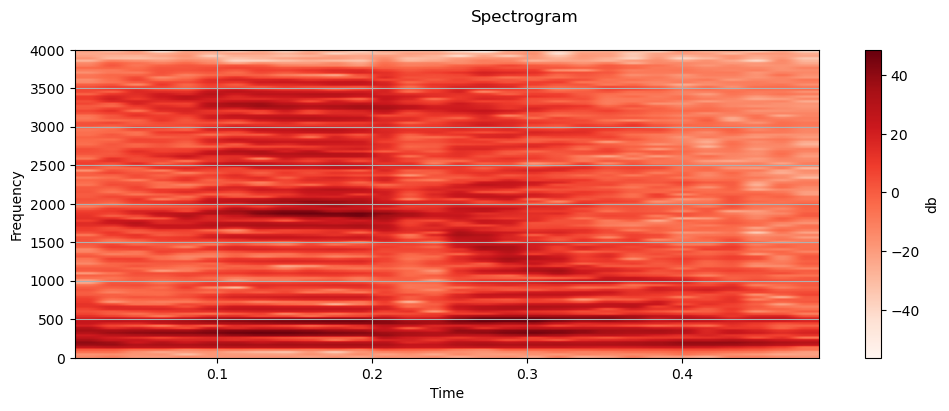

In [7]:
plt.figure(figsize=(12, 4))  
# Plot the spectrogram of power on log scale
powerSpectrum, frequenciesFound, time, imageAxis = plt.specgram(Audios[4], Fs=rate, scale = "dB",cmap="Reds")
# frequenciesFound gives all the found frequencies
# powerSpectrum gives the strength of a specific frequency for all time. powerSpectrum[index] where index corresponds to frequency
cbar = plt.gcf().colorbar(imageAxis)
cbar.set_label('db')
plt.grid()
plt.suptitle("Spectrogram")
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()   

In [11]:
print(f"Power spectrum at the time {time[0]}: ", powerSpectrum[0])
print("All frequencies found across the audio: ", frequenciesFound)

Power spectrum at the time 0.016:  [0.03258161 0.06673981 0.01203062 0.00957681 0.0260381  0.01291896
 0.01495868 0.01420306 0.01460106 0.00679944 0.0160798  0.00517254
 0.01921597 0.01232942 0.02098812 0.00373611 0.013442   0.01758832
 0.00376576 0.05809075 0.00285136 0.00725605 0.08329424 0.00871339
 0.00851326 0.00237232 0.05929346 0.05701229 0.02407494 0.01334727]
All frequencies found across the audio:  [   0.     31.25   62.5    93.75  125.    156.25  187.5   218.75  250.
  281.25  312.5   343.75  375.    406.25  437.5   468.75  500.    531.25
  562.5   593.75  625.    656.25  687.5   718.75  750.    781.25  812.5
  843.75  875.    906.25  937.5   968.75 1000.   1031.25 1062.5  1093.75
 1125.   1156.25 1187.5  1218.75 1250.   1281.25 1312.5  1343.75 1375.
 1406.25 1437.5  1468.75 1500.   1531.25 1562.5  1593.75 1625.   1656.25
 1687.5  1718.75 1750.   1781.25 1812.5  1843.75 1875.   1906.25 1937.5
 1968.75 2000.   2031.25 2062.5  2093.75 2125.   2156.25 2187.5  2218.75
 2250.   2

To analyze our system, we perform melspectrogram analysis.

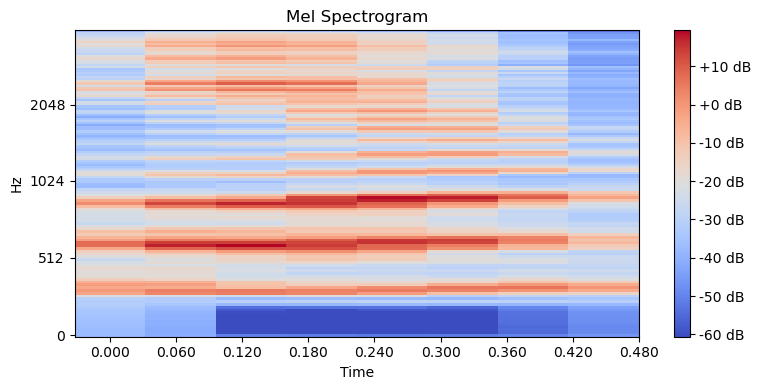

(128, 8)

In [13]:
mel = melspectrogram(y=Audios[3], n_fft= len(Audios[0]))
mel_db = power_to_db(mel, ref=np.mean)
plt.figure(figsize=(8, 4))
display.specshow(
    mel_db,
    sr=rate,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()
mel_db.shape

In [17]:
def ft_mean_std(Audios, n, f_s = 8000):
    """
    For each melspectrogram audio, we decompose it into an nxn block. For each block, we extract the mean and std. 
    Parameters:
        Audios: a set of audios 
        n: splitting nxn spectogram
    Returns: A 2-d numpy array - 500x(2*n*n) where 2 indicates mean and std for each block 
    and each melspectrogram has n*n blocks
    """
    Audios_sp = [] #feature matrix
    for Audio in Audios: # for each audio
        sp = power_to_db(melspectrogram(y=Audio, n_fft=len(Audio)), ref=np.mean) # perform melspectrogram
        Audio_sp = [] #current feature set
        # split the rows
        for v_split in np.array_split(sp, n, axis = 0): # split this spectrogram into n rows
            # split the columns
            for h_split in np.array_split(v_split, n, axis = 1): # split this spectrogram into n columns
                if h_split.size == 0: #happens when number of columns < n
                    m = np.median(v_split).__round__(4)
                    sd = np.std(v_split).__round__(4)
                else:
                    m = np.mean(h_split).__round__(4)
                    sd = np.std(h_split).__round__(4)
                Audio_sp.extend([m,sd]) # we add [mean,std,mean,std,...] for the current spectrogram
        Audios_sp.append(Audio_sp) # We perform the same for all the audios
    return np.array(Audios_sp)

In [19]:
# turn audios into a 2-d numpy array - 500x(2*n*n)
n = 7
X_ft = ft_mean_std(Audios, n)
print(X_ft)
# associate the vector of features with its target 
y_bar = []
for i in y:
    y_bar += [i]*n*n # we have n*n means and stds to predict a single target
y_bar = np.array(y_bar)
# Reshape into:
# num_samples × n blocks × 2 values: [mean, std]
X_blocks = X_ft.reshape(len(X_ft), n*n, 2)
# Extract means and stds separately into two vectors
X_mean = X_blocks[:, :, 0].reshape(-1)
X_std = X_blocks[:, :, 1].reshape(-1)
# Norm
max_mean = 0
min_mean = 0
for i in X_mean:
    if i >= max_mean:
        max_mean = i
    if i <= min_mean:
        min_mean = i
max_std = 0
min_std = 0
for i in X_std:
    if i >= max_std:
        max_std = i
    if i <= min_std:
        min_std = i
        
difference_mean = max_mean - min_mean
difference_std = max_std - min_std
X_mean = ((X_mean-min_mean)/difference_mean)
X_std = ((X_std-min_std)/difference_std)

print("Masked Target: ",y_bar)
print("Mean inputs: ", X_mean)
print("Std inputs: ", X_std)

[[-14.8845   8.6334 -17.7564 ...  10.0858 -16.2489  10.0858]
 [-31.9814  18.5326 -36.4241 ...   5.807  -34.7315   5.6756]
 [-40.7165  18.0548 -39.9405 ...   6.7723 -28.8727   5.9732]
 ...
 [-11.3039  13.8174 -11.2926 ...   4.7563 -29.7712   3.7591]
 [ -5.7776  14.4237  -5.5456 ...   1.6215 -29.339    1.8169]
 [-14.6158  13.3688 -13.1288 ...   6.0843 -26.2892   5.3794]]
Masked Target:  [0 0 0 ... 9 9 9]
Mean inputs:  [0.66026324 0.6208249  0.3887811  ... 0.54063797 0.5316898  0.50364804]
Std inputs:  [0.3164562  0.3904954  0.659128   ... 0.23440062 0.22301927 0.19718124]


By performing this analysis, we store them into joblib files. From now on, we extract these values from joblib files. We analyze the performance with methods SVM, RFC, and we compare these with our small quantum system.

In [17]:
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn import svm

In [22]:
from joblib import load

fold_data = load("5_fold_1_5speakers_36fts.joblib")
print(fold_data.keys())
for key in fold_data.keys():
    try:
        print(key, fold_data[key].shape)
    except:
        print(key, type(fold_data[key]))

dict_keys(['X_std_train', 'X_mean_train', 'X_skew_train', 'X_std_test', 'X_mean_test', 'X_skew_test', 'y_train', 'y_test'])
X_std_train (14400,)
X_mean_train (14400,)
X_skew_train (14400,)
X_std_test (3600,)
X_mean_test (3600,)
X_skew_test (3600,)
y_train (14400,)
y_test (3600,)


In [26]:
import numpy as np
from joblib import load
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

models = {
    "rfc": RFC(random_state=90),
    "svm": Pipeline([('scaler', StandardScaler()), ('SVM', svm.SVC(probability=True, random_state=99))])
}

def compute_WER(real_answer, prediction):
    substitution = 0
    for i in range(len(real_answer)):
        if real_answer[i] != prediction[i]:
            substitution += 1
    WER = substitution / len(real_answer)
    return WER, substitution


def run_rf_svm_on_joblib_folds(joblib_paths, num_ft):
    errors = {model_name: [] for model_name in models}
    all_results = {}
    for fold_idx, path in enumerate(joblib_paths, start=1):
        fold_data = load(path)
        X_mean_train = np.asarray(fold_data["X_mean_train"]).reshape(-1, num_ft)
        X_std_train  = np.asarray(fold_data["X_std_train"]).reshape(-1, num_ft)
        
        X_mean_test = np.asarray(fold_data["X_mean_test"]).reshape(-1, num_ft)
        X_std_test  = np.asarray(fold_data["X_std_test"]).reshape(-1, num_ft)
        # labels are repeated num_ft times, so take one label per sample
        y_train = np.asarray(fold_data["y_train"])[::num_ft].astype(int)
        y_test  = np.asarray(fold_data["y_test"])[::num_ft].astype(int)
        
        # combine mean and std features
        X_train = np.concatenate((X_mean_train, X_std_train), axis=1)
        X_test  = np.concatenate((X_mean_test, X_std_test), axis=1)
        
        print("=" * 50)
        print("Fold:", fold_idx)
        all_results[fold_idx] = {}
        for model_name, clf in models.items():
            clf.fit(X_train, y_train)
            prediction = clf.predict(X_test)
            real_answer = y_test
            WER, substitution = compute_WER(real_answer, prediction)
            errors[model_name].append(WER)
            all_results[fold_idx][model_name] = {
                "prediction": prediction,
                "real_answer": real_answer,
                "WER": WER,
                "substitution": substitution
            }

            print()
            print("Model:", model_name)
            print("Prediction:", prediction)
            print("Real answer:", real_answer)
            print("Substitution:", substitution)
            print("WER:", WER)
            print("Accuracy:", 1 - WER)
            print(classification_report(real_answer, prediction))
    summary = {}
    for model_name in models:
        fold_WERs = np.asarray(errors[model_name], dtype=float)
        summary[model_name] = {"fold_WERs": fold_WERs,"mean_WER": np.mean(fold_WERs),
            "std_WER": np.std(fold_WERs, ddof=1),"mean_accuracy": 1 - np.mean(fold_WERs)}
    return all_results, errors, summary

In [28]:
num_ft = 36
joblib_paths = [
    f"5_fold_1_5speakers_{num_ft}fts.joblib",
    f"5_fold_2_5speakers_{num_ft}fts.joblib",
    f"5_fold_3_5speakers_{num_ft}fts.joblib",
    f"5_fold_4_5speakers_{num_ft}fts.joblib",
    f"5_fold_0_5speakers_{num_ft}fts.joblib",
]
all_results, errors, summary = run_rf_svm_on_joblib_folds(joblib_paths,num_ft)
print(summary)

Fold: 1

Model: rfc
Prediction: [8 0 8 5 9 2 4 2 0 5 7 6 0 6 4 6 8 8 4 8 8 2 0 4 5 6 3 4 2 5 6 0 0 6 1 0 4
 1 5 5 5 1 5 2 9 3 4 1 4 0 0 0 1 8 5 5 2 0 0 7 1 7 2 8 5 5 4 7 5 9 8 8 2 3
 8 4 4 8 5 7 4 0 9 0 0 4 3 7 5 1 9 6 3 8 8 3 1 3 4 9]
Real answer: [8 6 8 5 9 2 4 2 0 1 7 6 0 6 4 6 7 8 4 8 8 2 0 4 1 6 3 4 2 9 6 0 3 6 1 0 4
 1 5 5 1 1 5 2 9 3 4 1 4 0 0 0 9 8 5 9 2 0 8 7 1 7 2 6 5 5 4 7 1 5 8 8 2 3
 8 4 4 8 5 7 4 3 9 0 0 4 6 7 5 1 8 6 3 8 8 3 1 3 4 9]
Substitution: 16
WER: 0.16
Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.73      1.00      0.85        11
           1       0.88      0.64      0.74        11
           2       1.00      1.00      1.00         8
           3       0.86      0.75      0.80         8
           4       1.00      1.00      1.00        14
           5       0.60      0.90      0.72        10
           6       1.00      0.70      0.82        10
           7       1.00      0.86      0.92         7
           8      

In [30]:
for model_name in summary:
    print("=" * 40)
    print("Model:", model_name)
    print("Fold WERs:", summary[model_name]["fold_WERs"])
    print("Mean WER:", summary[model_name]["mean_WER"])
    print("Std WER:", summary[model_name]["std_WER"])
    print("Mean Accuracy:", summary[model_name]["mean_accuracy"])

Model: rfc
Fold WERs: [0.16 0.17 0.14 0.14 0.15]
Mean WER: 0.15200000000000002
Std WER: 0.013038404810405297
Mean Accuracy: 0.848
Model: svm
Fold WERs: [0.03 0.09 0.08 0.16 0.12]
Mean WER: 0.096
Std WER: 0.04827007354458868
Mean Accuracy: 0.904


Averaging over many seeds

In [48]:
def make_models(seed):
    return {"rfc": RFC(random_state=seed),"svm": Pipeline([
            ("scaler", StandardScaler()),
            ("SVM", svm.SVC(probability=True,random_state=seed))])}

def run_rf_svm_on_joblib_folds_n_times(joblib_paths, num_ft, n_runs=10):
    # errors[model_name] will contain all WERs across runs and folds
    errors = {"rfc": [],"svm": []}
    run_fold_errors = {"rfc": [],"svm": []}
    all_results = {}
    for run_idx in range(n_runs):
        seed = 90 + run_idx
        models = make_models(seed)
        print("#" * 70)

        all_results[run_idx] = {}
        # temporary fold errors for this run
        current_run_errors = {"rfc": [],"svm": []}

        for fold_idx, path in enumerate(joblib_paths, start=1):
            fold_data = load(path)
            X_mean_train = np.asarray(fold_data["X_mean_train"]).reshape(-1, num_ft)
            X_std_train  = np.asarray(fold_data["X_std_train"]).reshape(-1, num_ft)

            X_mean_test = np.asarray(fold_data["X_mean_test"]).reshape(-1, num_ft)
            X_std_test  = np.asarray(fold_data["X_std_test"]).reshape(-1, num_ft)

            # labels are repeated num_ft times, so take one label per sample
            y_train = np.asarray(fold_data["y_train"])[::num_ft].astype(int)
            y_test  = np.asarray(fold_data["y_test"])[::num_ft].astype(int)

            # combine mean and std features
            X_train = np.concatenate((X_mean_train, X_std_train), axis=1)
            X_test  = np.concatenate((X_mean_test, X_std_test), axis=1)

            print("=" * 50)
            print("Run:", run_idx + 1)
            print("Fold:", fold_idx)

            all_results[run_idx][fold_idx] = {}

            for model_name, clf in models.items():
                clf.fit(X_train, y_train)

                prediction = clf.predict(X_test)
                real_answer = y_test

                WER, substitution = compute_WER(real_answer, prediction)

                errors[model_name].append(WER)
                current_run_errors[model_name].append(WER)

                all_results[run_idx][fold_idx][model_name] = {
                    "prediction": prediction,
                    "real_answer": real_answer,
                    "WER": WER,
                    "substitution": substitution
                }

                print()
                print("Model:", model_name)
                print("Prediction:", prediction)
                print("Real answer:", real_answer)
                print("Substitution:", substitution)
                print("WER:", WER)
                print("Accuracy:", 1 - WER)

        # save fold WERs for this run
        for model_name in current_run_errors:
            run_fold_errors[model_name].append(current_run_errors[model_name])

    summary = {}
    for model_name in errors:
        all_WERs = np.asarray(errors[model_name], dtype=float)
        run_fold_WERs = np.asarray(run_fold_errors[model_name], dtype=float)
        run_mean_WERs = np.mean(run_fold_WERs, axis=1)

        summary[model_name] = {
            "all_WERs": all_WERs,
            "run_fold_WERs": run_fold_WERs,
            "run_mean_WERs": run_mean_WERs,
            "mean_WER_over_all_runs_folds": np.mean(all_WERs),
            "std_WER_over_all_runs_folds": np.std(all_WERs, ddof=1),
            "mean_WER_across_runs": np.mean(run_mean_WERs),
            "std_WER_across_runs": np.std(run_mean_WERs, ddof=1),
            "mean_accuracy": 1 - np.mean(run_mean_WERs)
        }

    return all_results, errors, run_fold_errors, summary

In [50]:
all_results, errors, run_fold_errors, summary = run_rf_svm_on_joblib_folds_n_times(
    joblib_paths,num_ft,n_runs=50)

######################################################################
Run: 1
Fold: 1

Model: rfc
Prediction: [8 0 8 5 9 2 4 2 0 5 7 6 0 6 4 6 8 8 4 8 8 2 0 4 5 6 3 4 2 5 6 0 0 6 1 0 4
 1 5 5 5 1 5 2 9 3 4 1 4 0 0 0 1 8 5 5 2 0 0 7 1 7 2 8 5 5 4 7 5 9 8 8 2 3
 8 4 4 8 5 7 4 0 9 0 0 4 3 7 5 1 9 6 3 8 8 3 1 3 4 9]
Real answer: [8 6 8 5 9 2 4 2 0 1 7 6 0 6 4 6 7 8 4 8 8 2 0 4 1 6 3 4 2 9 6 0 3 6 1 0 4
 1 5 5 1 1 5 2 9 3 4 1 4 0 0 0 9 8 5 9 2 0 8 7 1 7 2 6 5 5 4 7 1 5 8 8 2 3
 8 4 4 8 5 7 4 3 9 0 0 4 6 7 5 1 8 6 3 8 8 3 1 3 4 9]
Substitution: 16
WER: 0.16
Accuracy: 0.84

Model: svm
Prediction: [3 3 3 5 3 2 4 2 0 2 7 6 0 6 4 6 2 8 2 3 6 2 2 4 2 6 3 4 2 9 2 0 3 6 1 0 4
 1 2 9 9 1 2 2 9 3 4 2 4 0 2 2 9 8 5 9 2 0 2 7 1 9 2 6 3 3 2 7 2 9 8 8 2 3
 3 2 4 2 5 3 4 2 9 0 2 4 2 3 5 7 8 6 3 3 8 3 2 3 4 2]
Real answer: [8 6 8 5 9 2 4 2 0 1 7 6 0 6 4 6 7 8 4 8 8 2 0 4 1 6 3 4 2 9 6 0 3 6 1 0 4
 1 5 5 1 1 5 2 9 3 4 1 4 0 0 0 9 8 5 9 2 0 8 7 1 7 2 6 5 5 4 7 1 5 8 8 2 3
 8 4 4 8 5 7 4 3 9 0 0 4 6 7 5 1 8 6

KeyboardInterrupt: 

In [41]:
summary

{'rfc': {'all_WERs': array([0.16, 0.17, 0.14, 0.14, 0.15, 0.1 , 0.16, 0.11, 0.17, 0.15, 0.1 ,
         0.17, 0.12, 0.13, 0.14, 0.14, 0.14, 0.15, 0.16, 0.12, 0.11, 0.13,
         0.16, 0.17, 0.12, 0.17, 0.18, 0.12, 0.17, 0.12, 0.1 , 0.19, 0.16,
         0.19, 0.14, 0.12, 0.15, 0.1 , 0.15, 0.16, 0.13, 0.15, 0.15, 0.15,
         0.15, 0.09, 0.19, 0.14, 0.18, 0.12, 0.12, 0.17, 0.13, 0.15, 0.12,
         0.1 , 0.11, 0.12, 0.19, 0.12, 0.12, 0.18, 0.13, 0.15, 0.15, 0.11,
         0.12, 0.14, 0.13, 0.15, 0.14, 0.12, 0.12, 0.14, 0.11, 0.13, 0.16,
         0.12, 0.19, 0.15, 0.1 , 0.14, 0.15, 0.17, 0.11, 0.12, 0.2 , 0.12,
         0.15, 0.15, 0.09, 0.13, 0.12, 0.18, 0.14, 0.1 , 0.15, 0.09, 0.18,
         0.15, 0.13, 0.15, 0.14, 0.13, 0.13, 0.12, 0.13, 0.16, 0.15, 0.11,
         0.13, 0.16, 0.15, 0.15, 0.11, 0.15, 0.14, 0.14, 0.17, 0.15, 0.14,
         0.16, 0.11, 0.14, 0.1 , 0.1 , 0.13, 0.18, 0.13, 0.12, 0.14, 0.17,
         0.16, 0.16, 0.15, 0.12, 0.15, 0.13, 0.21, 0.16, 0.13, 0.14, 0.13,
      